In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists() and (PROJECT_ROOT.parent / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import wasserstein_distance

from comet_ml import Experiment

from scripts.utils import AgingFactorGenerator, aggregate_cell_stats, get_cellid_counts_per_event, filter_by_xyz
from scripts.plot_graphics import PlotGenerator, plot_true_vs_predicted, plot_error_histogram

/home/akarbyshev/miniconda3/envs/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/akarbyshev/miniconda3/envs/myenv/lib/python3.9/site-packages/comet_ml/env_logging.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os

os.environ["COMET_API_KEY"] = "ZvzFX4CUjN8omegkDEAzWRoTf"
os.environ["COMET_WORKSPACE"] = "redroseonmyhand"
os.environ["COMET_PROJECT_NAME"] = "calorimeter-wgan"

In [ ]:
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)
df = pd.read_csv(PROJECT_ROOT / config["data_path"])
aging_cfg = config.get("aging", {})
results_dir = PROJECT_ROOT / config["results_dir"]
results_dir.mkdir(exist_ok=True)

In [4]:
generator = AgingFactorGenerator(
    aging_function=aging_cfg.get("function", "xyz"),
    af_min=aging_cfg.get("af_min", 0.8),
    af_max=aging_cfg.get("af_max", 1.0),
    sigma=aging_cfg.get("sigma", 0.0),
    noise_seed=aging_cfg.get("noise_seed"),
    event_col=aging_cfg.get("event_col", "event"),
    x_col=aging_cfg.get("x_col", "x"),
    y_col=aging_cfg.get("y_col", "y"),
    z_col=aging_cfg.get("z_col", "z"),
    energy_col=aging_cfg.get("energy_col", "E"),
)
aged = generator.generate(df)
subset = generator.sample_events(aged, n_events=aging_cfg.get("n_events"), seed=aging_cfg.get("noise_seed"))
dataset = subset[[generator.event_col, "cell_key", generator.x_col, generator.y_col, generator.z_col, "E_new", "E_old", "aging_factor"]]
dataset

,event,cell_key,x,y,z,E_new,E_old,aging_factor
0,0,"(7.5, -25.5, -136.4915)",7.5,-25.5,-136.4915,682.457989,571.407704,0.837279
1,0,"(-4.5, -16.5, -131.4905)",-4.5,-16.5,-131.4905,219.605838,179.293504,0.816433
2,0,"(-4.5, -13.5, -131.4905)",-4.5,-13.5,-131.4905,1274.081248,1033.467502,0.811147
3,0,"(-1.5, -16.5, -131.4905)",-1.5,-16.5,-131.4905,447.282884,364.717012,0.815406
4,0,"(-1.5, -16.5, -126.4895)",-1.5,-16.5,-126.4895,627.502513,511.926561,0.815816
...,...,...,...,...,...,...,...,...
11866301,999985,"(19.5, 16.5, -96.48350000000002)",19.5,16.5,-96.4835,335.399827,281.055924,0.837973
11866302,999985,"(7.5, 10.5, -91.48250000000002)",7.5,10.5,-91.4825,981.900816,797.489144,0.812189
11866303,999985,"(16.5, 13.5, -91.48250000000002)",16.5,13.5,-91.4825,464.270047,384.640009,0.828483
11866304,999985,"(10.5, -22.5, -76.47950000000002)",10.5,-22.5,-76.4795,545.124213,456.740264,0.837865


In [5]:
x_range = (-30, 30)
y_range = (-30, 30)
z_range = (-100, -80)

dataset = filter_by_xyz(dataset, x_range, y_range, z_range)

In [6]:
k = 90000
seed_new = 42
seed_old = 123
event_col = generator.event_col

In [7]:
unique_events = dataset[event_col].drop_duplicates()

events_new = unique_events.sample(n=k, random_state=seed_new)
events_old = unique_events.sample(n=k, random_state=seed_old)

data_E_new = dataset[dataset[event_col].isin(events_new)].copy().reset_index(drop=True)
data_E_old = dataset[dataset[event_col].isin(events_old)].copy().reset_index(drop=True)

In [8]:
base_cols = [event_col, "cell_key", "x", "y", "z"]

data_E_new = data_E_new[base_cols + ["E_new"]] \
    .rename(columns={"E_new": "E"})

data_E_old = data_E_old[base_cols + ["E_old"]] \
    .rename(columns={"E_old": "E"})

Mean Model

In [9]:
mean_new = (
    data_E_new
    .groupby("cell_key")["E"]
    .mean()
    .rename("mu_new")
)

mean_old = (
    data_E_old
    .groupby("cell_key")["E"]
    .mean()
    .rename("mu_old")
)

In [10]:
mean_df = pd.concat([mean_new, mean_old], axis=1)

mean_df = mean_df.dropna()

counts_new = data_E_new.groupby("cell_key")["E"].size()
counts_old = data_E_old.groupby("cell_key")["E"].size()

mean_df = mean_df.join(counts_new.rename("n_new"))
mean_df = mean_df.join(counts_old.rename("n_old"))


mean_df["a_hat_mean"] = mean_df["mu_old"] / mean_df["mu_new"]

In [11]:
a_true = (
    dataset
    .groupby("cell_key")["aging_factor"]
    .mean()
    .rename("a_true")
)

mean_df = mean_df.join(a_true, how="inner")

In [12]:
mean_df

,mu_new,mu_old,n_new,n_old,a_hat_mean,a_true
cell_key,,,,,,
"(-28.5, -28.5, -96.48350000000002)",1607.066565,1409.459657,68,68,0.877039,0.880317
"(-28.5, -28.5, -91.48250000000002)",2130.520446,1942.818151,51,49,0.911898,0.880727
"(-28.5, -28.5, -86.48150000000001)",1507.643303,1562.852651,52,52,1.036620,0.881138
"(-28.5, -28.5, -81.48050000000002)",835.799032,751.600105,46,43,0.899259,0.881548
"(-28.5, -25.5, -96.48350000000002)",1935.977287,1734.981937,83,82,0.896179,0.873727
...,...,...,...,...,...,...
"(28.5, 25.5, -81.48050000000002)",1790.225787,1540.343934,38,39,0.860419,0.874958
"(28.5, 28.5, -96.48350000000002)",1498.654954,981.124147,57,55,0.654670,0.880317
"(28.5, 28.5, -91.48250000000002)",2075.648873,1931.716875,60,55,0.930657,0.880727


In [13]:
rmse_mean = np.sqrt(np.mean((mean_df["a_true"] - mean_df["a_hat_mean"])**2))
rmse_mean

np.float64(0.041976316159926655)

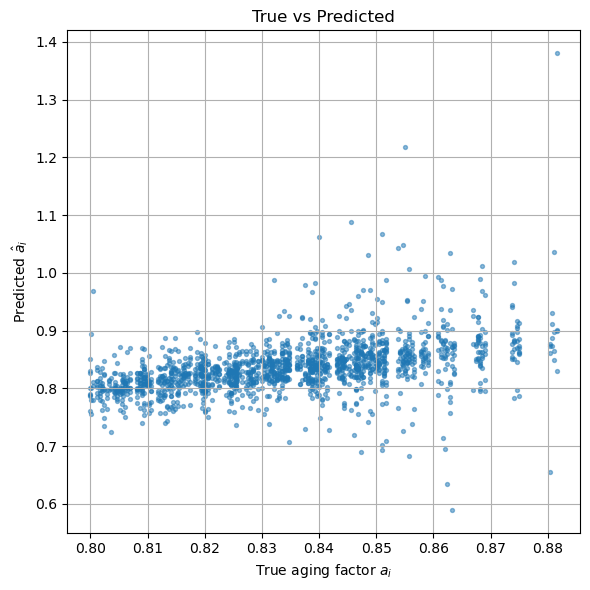

In [14]:
plot_true_vs_predicted(mean_df, "a_true", "a_hat_mean")

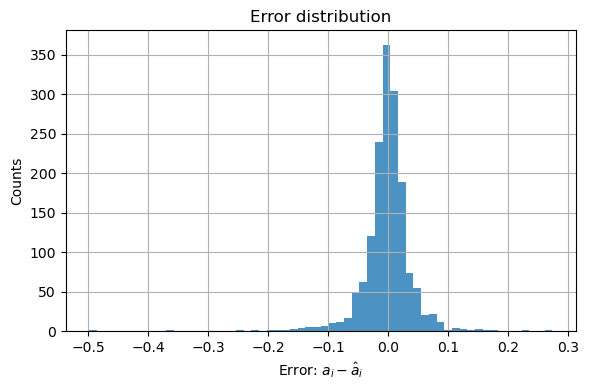

In [15]:
plot_error_histogram(mean_df, "a_true", "a_hat_mean")

Median Model

In [16]:
median_new = (
    data_E_new
    .groupby("cell_key")["E"]
    .median()
    .rename("m_new")
)

median_old = (
    data_E_old
    .groupby("cell_key")["E"]
    .median()
    .rename("m_old")
)

median_df = pd.concat([median_new, median_old], axis=1)

median_df = median_df.dropna()

median_df = median_df.join(counts_new.rename("n_new"))
median_df = median_df.join(counts_old.rename("n_old"))

median_df["a_hat_median"] = median_df["m_old"] / median_df["m_new"]


a_true = (
    dataset
    .groupby("cell_key")["aging_factor"]
    .mean()
    .rename("a_true")
)

median_df = median_df.join(a_true, how="inner")

In [17]:
rmse_median = np.sqrt(np.mean((median_df["a_true"] - median_df["a_hat_median"])**2))
rmse_median

np.float64(0.03430988913190482)

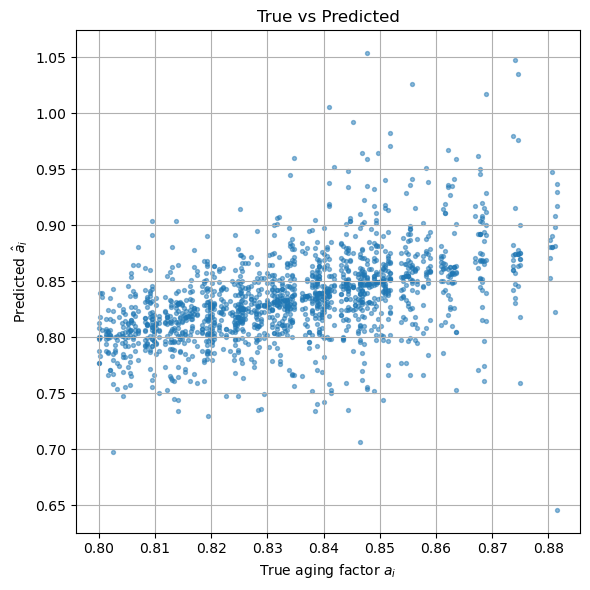

In [18]:
plot_true_vs_predicted(median_df, "a_true", "a_hat_median")

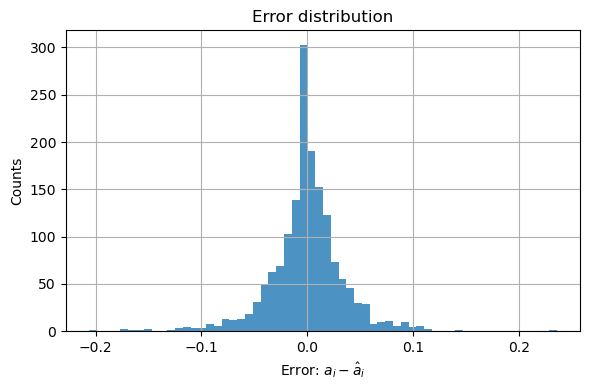

In [19]:
plot_error_histogram(median_df, "a_true", "a_hat_median")

Wasserstein Distance Model

In [20]:
alpha_grid = np.arange(0.80, 1.001, 0.01)

In [21]:
group_new = data_E_new.groupby("cell_key")["E"]
group_old = data_E_old.groupby("cell_key")["E"]

common_cells = sorted(
    set(group_new.groups.keys()) & set(group_old.groups.keys())
)

In [22]:
a_hat_wasserstein = {}

for cell in common_cells:
    X_new = group_new.get_group(cell).values
    X_old = group_old.get_group(cell).values

    W_vals = []

    for alpha in alpha_grid:
        W = wasserstein_distance(X_new, X_old / alpha)
        W_vals.append(W)

    best_alpha = alpha_grid[np.argmin(W_vals)]
    a_hat_wasserstein[cell] = best_alpha

In [23]:
best_alpha

np.float64(0.8800000000000001)

In [24]:
wasserstein_df = pd.DataFrame.from_dict(
    a_hat_wasserstein,
    orient="index",
    columns=["a_hat_wasserstein"]
)

In [25]:
a_true = (
    dataset
    .groupby("cell_key")["aging_factor"]
    .mean()
    .rename("a_true")
)

wasserstein_df = wasserstein_df.join(a_true, how="inner")

In [26]:
rmse_wasserstein = np.sqrt(np.mean((wasserstein_df["a_true"] - wasserstein_df["a_hat_wasserstein"])**2))
rmse_wasserstein

np.float64(0.01756540228818443)

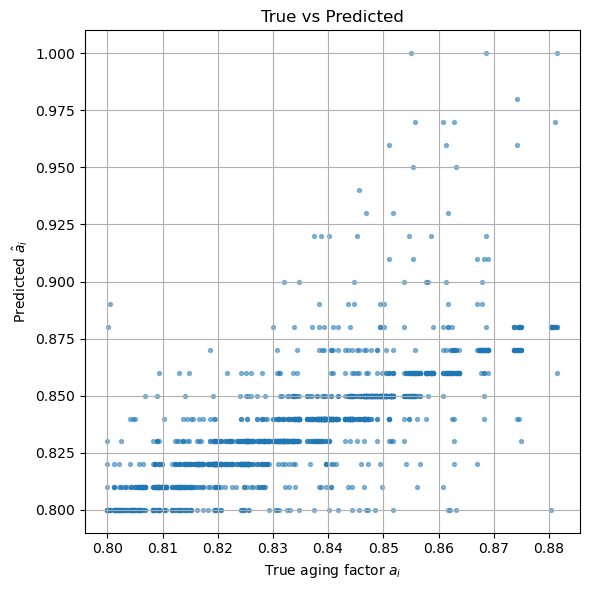

In [27]:
plot_true_vs_predicted(wasserstein_df, "a_true", "a_hat_wasserstein")

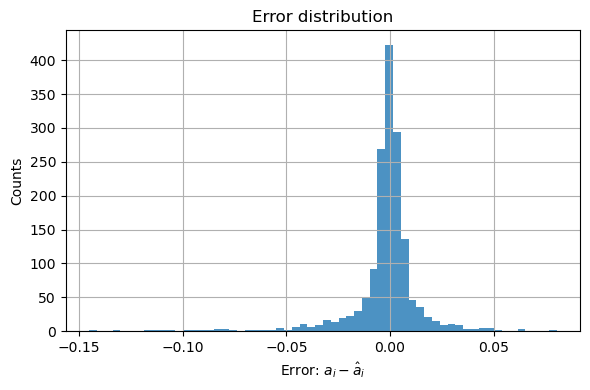

In [28]:
plot_error_histogram(wasserstein_df, "a_true", "a_hat_wasserstein")

WGAN Model

In [29]:
use_gradient_penalty = True
gp_lambda = 10.0
clip_value = 0.01

n_epochs = 30
batch_size = 512

In [30]:
experiment = Experiment(
    experiment_name="wgan_gp_run_001",
    auto_param_logging=False,
    auto_metric_logging=False,
    log_env_details=False,
)

experiment.log_parameters({
    "n_epochs": n_epochs,
    "batch_size": batch_size,
    "gp_lambda": gp_lambda ,
    "use_gradient_penalty": use_gradient_penalty,
    "clip_value": clip_value,
})

global_step = 0

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/redroseonmyhand/calorimeter-wgan/143c0c4364d1411a877d4f49a4865088

COMET INFO: Couldn't find a Git repository in '/home/akarbyshev/wgan' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


In [31]:
x_vals = np.sort(dataset['x'].unique())
y_vals = np.sort(dataset['y'].unique())
z_vals = np.sort(dataset['z'].unique())

NX, NY, NZ = len(x_vals), len(y_vals), len(z_vals)

x_map = {v: i for i, v in enumerate(x_vals)}
y_map = {v: i for i, v in enumerate(y_vals)}
z_map = {v: i for i, v in enumerate(z_vals)}

print("NX, NY, NZ =", NX, NY, NZ)
print("x range:", x_vals[0], x_vals[-1])
print("y range:", y_vals[0], y_vals[-1])
print("z range:", z_vals[0], z_vals[-1])

NX, NY, NZ = 20 20 4
x range: -28.5 28.5
y range: -28.5 28.5
z range: -96.48350000000002 -81.48050000000002


In [32]:
def build_real_aging_tensor(df):
    real_W = torch.ones(NZ, NX, NY)

    cell_df = (
        df[['cell_key','x','y','z','aging_factor']]
        .drop_duplicates('cell_key')
        .reset_index(drop=True)
    )

    for _, row in tqdm(cell_df.iterrows(),
                       total=len(cell_df),
                       desc="Building real aging tensor"):
        x, y, z = row[['x','y','z']]
        a = row['aging_factor']

        iz = z_map[z]
        ix = x_map[x]
        iy = y_map[y]

        real_W[iz, ix, iy] = float(a)

    return real_W

real_W = build_real_aging_tensor(dataset)

Building real aging tensor: 100%|██████████| 1600/1600 [00:00<00:00, 1636.10it/s]


In [33]:
class CaloEventDataset(Dataset):
    def __init__(self, df):
        self.events = []
        for eid, ev in df.groupby('event', sort=False):
            self.events.append(ev[['x','y','z','E_new','E_old']].to_numpy())

    def __len__(self):
        return len(self.events)

    def __getitem__(self, idx):
        ev = self.events[idx]

        E_new = torch.zeros(NZ, NX, NY)
        E_old = torch.zeros(NZ, NX, NY)
        mask  = torch.zeros(NZ, NX, NY)

        for x, y, z, en, eo in ev:
            iz = z_map[z]
            ix = x_map[x]
            iy = y_map[y]
            E_new[iz, ix, iy] = float(en)
            E_old[iz, ix, iy] = float(eo)
            mask[iz, ix, iy] = 1.0

        return {'E_new': E_new, 'E_old': E_old, 'mask': mask}

In [34]:
train_ds = CaloEventDataset(dataset)
loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

print("num events:", len(train_ds))

num events: 94277


In [35]:
class Generator(nn.Module):
    def __init__(self, shape, eps=1e-8):
        super().__init__()
        self.W = nn.Parameter(torch.ones(shape))
        self.eps = eps

    def forward(self, E_old):
        B = E_old.size(0)
        W = self.W.unsqueeze(0).expand(B, -1, -1, -1)
        return E_old / (W + self.eps)

In [36]:
class Discriminator(nn.Module):
    def __init__(self, in_dim=NZ, dim=64):
        super().__init__()

        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1),
                nn.InstanceNorm2d(o, affine=True),
                nn.LeakyReLU(0.2)
            )

        self.net = nn.Sequential(
            nn.Conv2d(in_dim, dim, 3, padding=1),
            nn.LeakyReLU(0.2),
            block(dim, dim*2),
            block(dim*2, dim*2),
            block(dim*2, dim),
            nn.Conv2d(dim, 1, 4),
            nn.AdaptiveMaxPool2d(1)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

G = Generator((NZ, NX, NY)).to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

print("device:", device)

device: cuda


In [38]:
def gradient_penalty(D, real, fake, device):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    interp = eps * real + (1 - eps) * fake
    interp.requires_grad_(True)

    d_interp = D(interp)

    grads = torch.autograd.grad(
        outputs=d_interp,
        inputs=interp,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [ ]:
def rmse_mae(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    rmse = float(np.sqrt(np.mean((a - b) ** 2)))
    mae = float(np.mean(np.abs(a - b)))
    return rmse, mae

history = {'D_loss': [], 'G_loss': [], 'W_rmse': [], 'W_mae': []}

real_W_np = real_W.numpy()

for epoch in range(n_epochs):
    D_losses = []
    G_losses = []

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    for batch in pbar:
        E_new = batch['E_new'].to(device)
        E_old = batch['E_old'].to(device)

        mask = ((E_new != 0) & (E_old != 0)).float()
        E_new = E_new * mask
        E_old = E_old * mask

        opt_D.zero_grad()

        fake = G(E_old).detach()
        d_real = D(E_new)
        d_fake = D(fake)

        d_loss = -d_real.mean() + d_fake.mean()

        if use_gradient_penalty:
            gp = gradient_penalty(D, E_new, fake, device)
            d_loss = d_loss + gp_lambda * gp

        d_loss.backward()
        opt_D.step()

        if not use_gradient_penalty:
            for p in D.parameters():
                p.data.clamp_(-clip_value, clip_value)

        opt_G.zero_grad()
        fake = G(E_old)
        g_loss = -D(fake).mean()
        g_loss.backward()
        opt_G.step()

        with torch.no_grad():
            G.W.clamp_(0.0, 1.0)

        D_losses.append(float(d_loss.item()))
        G_losses.append(float(g_loss.item()))
        pbar.set_postfix(D=np.mean(D_losses), G=np.mean(G_losses))
        
        experiment.log_metrics(
            {
                "train/D_loss_step": float(d_loss.item()),
                "train/G_loss_step": float(g_loss.item()),
            },
            step=global_step,
            epoch=epoch,
        )
        global_step += 1


    with torch.no_grad():
        W_pred = G.W.detach().cpu().numpy()
    w_rmse, w_mae = rmse_mae(W_pred, real_W_np)

    history['D_loss'].append(float(np.mean(D_losses)))
    history['G_loss'].append(float(np.mean(G_losses)))
    history['W_rmse'].append(w_rmse)
    history['W_mae'].append(w_mae)
    
    experiment.log_metrics(
        {
            "train/D_loss_epoch": history["D_loss"][-1],
            "train/G_loss_epoch": history["G_loss"][-1],
            "metrics/W_rmse": w_rmse,
            "metrics/W_mae": w_mae,
        },
        epoch=epoch,
    )

    print(f"Epoch {epoch+1}: D={history['D_loss'][-1]:.4f}  G={history['G_loss'][-1]:.4f}  W_RMSE={w_rmse:.4f}  W_MAE={w_mae:.4f}")

experiment.end()

Epoch 1/30: 100%|██████████| 185/185 [01:07<00:00,  2.74it/s, D=6.79, G=-9.44]


Epoch 1: D=6.7890  G=-9.4438  W_RMSE=0.1629  W_MAE=0.1619


Epoch 2/30: 100%|██████████| 185/185 [00:56<00:00,  3.29it/s, D=5.46, G=-9.87]


Epoch 2: D=5.4622  G=-9.8736  W_RMSE=0.1617  W_MAE=0.1606


Epoch 3/30: 100%|██████████| 185/185 [00:56<00:00,  3.28it/s, D=5, G=-10.6]   


...

Epoch 19/30: 100%|██████████| 185/185 [00:58<00:00,  3.17it/s, D=0.134, G=-18.2]


Epoch 19: D=0.1344  G=-18.1856  W_RMSE=0.0257  W_MAE=0.0208


Epoch 20/30: 100%|██████████| 185/185 [00:57<00:00,  3.19it/s, D=0.134, G=-19.3]


Epoch 20: D=0.1341  G=-19.3204  W_RMSE=0.0251  W_MAE=0.0202


Epoch 21/30:  11%|█         | 20/185 [00:06<00:52,  3.16it/s, D=0.268, G=-20.3]